In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, 'src')

from FDEM1D import FDEM1D, FDEM1DModelling, LCModelling
from showStitched import showStitchedModels
from Plot import Plot_Datas

In [3]:
# First step: check configuration of FDEM to perform forward
# Second step: check number of layers in FDEM1D Modelling forward class

In [149]:
## Create a test model

pos = 10
nLayers = 3

x =  np.linspace(0,pos,pos, endpoint=False)
sigm_1 = 200/1000
sigm_2 = 1250/1000
sigm_3 = 100/1000
sigm_4 = 25/1000
thk_1 = 2* np.ones(pos) - [0.5, 0.6, 0.7, .8, .9, 1, 0.9, 0.8, 0.7, 0.6]
thk_2 = 1*np.ones(pos) + 2*np.array([0.5, 0.6, 0.7, .8, .9, 1, 0.9, 0.8, 0.7, 0.6])
thk_3 = np.ones_like(x)*2

models = np.zeros((pos, nLayers*2-1))
models[:,0] = thk_1
models[:,1] = thk_2
#models[:,2] = thk_3
models[:,2] = sigm_1
models[:,3] = sigm_1
models[:,3] = sigm_2
models[:,4] = sigm_3
#models[:,6] = sigm_4

nSoundings = pos

## Create test data

data_t = []

# 3 lay case
for p in range(pos):
    data_t.append(FDEM1D(models[p,2:], models[p,:2]))

# 4 lay case
#for p in range(pos):
#    data_t.append(FDEM1D(models[p,3:], models[p,:3]))



In [150]:
#np.save('modelLCI', models)

In [151]:
#np.save('dataLCI', data_t)
#data_3D = np.load('dataLCI_3D.npy').reshape(np.shape(data_t))

<AxesSubplot:title={'center':'True Model'}>

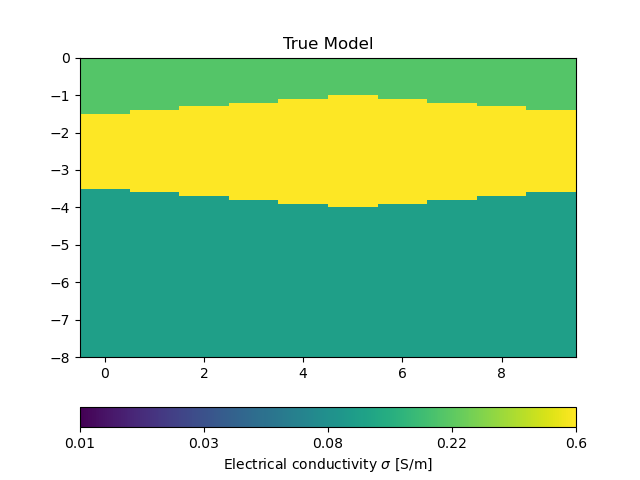

In [152]:
inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 10/1000,
         'cMax': 600/1000}

showStitchedModels(models, zMax=8, title = 'True Model', **inputs)

# LCI

In [153]:
LC = LCModelling(FDEM1DModelling)

Inversion is normalized


In [154]:
LC.initJacobian(dataVals=data_t, nLay=nLayers)
LC.createJacobian(models)
LC.constraint_matrix(data_t, nLay=nLayers)
LC.normalization(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LC.createWeight(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LC.createConstraints()


Jacobian size: 162 45 180
cWeights are equal
Constraint cWeight length: 45
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f0fee1d7a40>


In [155]:
RM = LC.regionManager()
RM.regionIdxs()

2 [1, 2]

# Inversion

In [156]:
# Initial model
m0 = models.copy()

# 3 lay case
m0[:,:2] = 2
m0[:,2:] = 500/1000

m0 = m0.ravel()

# 4 lay case
#m0[:,:3] = 2
#m0[:,3:] = 50/1000

In [157]:
transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(1,4)
transSig = pg.trans.TransLogLU(100/1000,1250/1000)

LC.region(1).setTransModel(transThk)
LC.region(2).setTransModel(transSig)

data_true = np.array(data_t).ravel()
relativeError = np.ones_like(data_true)*1e-3 # what is this for?


inv = pg.Inversion(LC)
inv.dataTrans = transData
models_est = inv.run(data_true, relativeError, startModel=m0, verbose=False)

11/03/24 - 18:11:14 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
11/03/24 - 18:11:14 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
11/03/24 - 18:11:14 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


<AxesSubplot:title={'center':'True Model LCI'}>

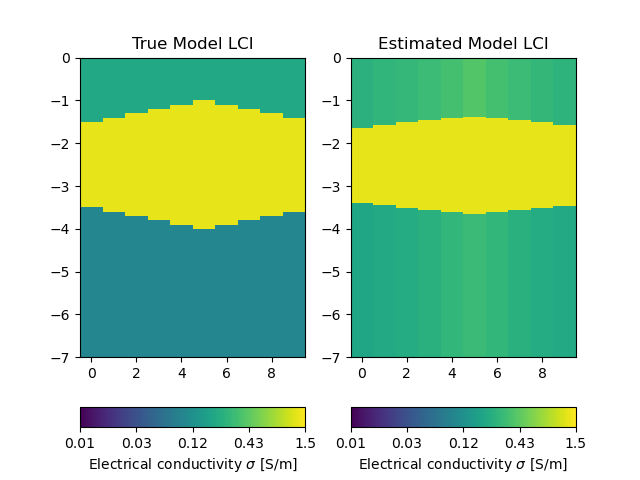

In [158]:
models_est = np.array(models_est).reshape(np.shape(models))

fig, ax = plt.subplots(1,2)

inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 10/1000,
         'cMax': 1500/1000, 
         'logScale':True}

showStitchedModels(ax = ax[1], models=models_est, zMax=7, 
                  title = 'Estimated Model LCI', **inputs)

showStitchedModels(ax = ax[0], models=models, zMax=7, 
                  title = 'True Model LCI', **inputs)


In [159]:
# Define inversion
#LC.region(1).setConstraintType(10)
#LC.region(2).setConstraintType(10)

# Why is the behaviour so strange ??? when you change the limits

Lcurve = True

chi2 = 1.1
dPhi = 2.1
phi0 = 0
chi2s = []
phis = []
maxIter = 20
ii = 0

while Lcurve and (chi2 > 1) and (dPhi > 2) and (ii < maxIter):
    
    print('started inversion ...')
    print('Iteration number: ', ii+1)
    
    #print('Running L-curve criterion')
    lambdas = np.logspace(-1,3,20)
        
    phimodels = []
    phidatas = []
    chis = []
    mods = {}

    for i, a in enumerate(lambdas):
        #print(f'Now using LAMBDA {a} - {i} ITERATION')
        inv = pg.Inversion(LC)
        inv.dataTrans = transData
        mod = inv.run(data_true, relativeError, startModel=m0, verbose=False, lam=a)
        phimodels.append(inv.phiModel())
        phidatas.append(inv.phiData())
        chis.append(inv.chi2())
        mods[a] = mod

    # first derivatives
    dx = np.gradient(phimodels)
    dy = np.gradient(phidatas)

    # second derivatives
    d2x = np.gradient(dx)
    d2y = np.gradient(dy)

    # calculation of curvature
    curvature = np.abs(dx * d2y - d2x * dy)/(dx * dx + dy * dy)**1.5
    print('The optimal alpha =', lambdas[np.argmax(curvature)+1])

    lamb_opt = lambdas[np.argmax(curvature)+1]
    
    inv = pg.Inversion(LC)
    inv.dataTrans = transData
    models_est = inv.run(data_true, relativeError, startModel=m0, 
                         verbose=False, lam=lamb_opt, maxIter=1)
    
    chi2 = inv.chi2()
    chi2s.append(chi2)
    print('Chi2: ', chi2)
    
    phi1 = inv.phi()
    dPhi = np.abs((phi1 - phi0)/phi1)*100
    phis.append(phi1)
    print('dPhi: ', dPhi)

    phi0 = phi1
    m0 = models_est.copy()
    
    ii +=1
    

#plt.figure()
#plt.scatter(phimodels, phidatas, c='g')
#plt.xlabel('Phi Model')
#plt.ylabel('Phi Data')
#plt.title('L-curve analysis')
#for i, txt in enumerate(lambdas):
#    txt = np.round(txt,3)
#    txt = str(txt)
#    plt.annotate(txt, (phimodels[i], phidatas[i]))
#plt.plot(phimodels[np.argmax(curvature)+1], phidatas[np.argmax(curvature)+1], 'b')
#plt.show()


11/03/24 - 18:11:21 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
11/03/24 - 18:11:21 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
11/03/24 - 18:11:21 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


started inversion ...
Iteration number:  1


11/03/24 - 18:11:26 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
11/03/24 - 18:11:26 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
11/03/24 - 18:11:26 - Core - ERROR - no cWeights defined. You should create constraints matrix first.
11/03/24 - 18:11:30 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
11/03/24 - 18:11:30 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
11/03/24 - 18:11:30 - Core - ERROR - no cWeights defined. You should create constraints matrix first.
11/03/24 - 18:11:32 - Core - WARNING - no clear() implemente

The optimal alpha = 0.42813323987193935


11/03/24 - 18:12:18 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
11/03/24 - 18:12:18 - pyGIMLi - INFO - Starting model set from given array. 50 [2.0, 2.0, 0.33328988641444074, 1.1185277225399324, 0.2787846304957207, 2.0, 2.0, 0.350652971227263, 1.151887207024605, 0.27740868694390813, 2.0, 2.0, 0.3741797340112622, 1.1667426996659853, 0.29140498401502696, 2.0, 2.0, 0.4065486273139698, 1.1661146389422172, 0.3320413185283597, 2.0, 2.0, 0.4524848001077828, 1.14276652561698, 0.42977896788750786, 2.0, 2.0, 0.5222112535695722, 1.0591159000629602, 0.6527842539891735, 2.0, 2.0, 0.4524848038545128, 1.1427665261684015, 0.4297789687820812, 2.0, 2.0, 0.406544084701354, 1.166114188364766, 0.33204049339162556, 2.0, 2.0, 0.37418254042390503, 1.1667435772593095, 0.291392849584694, 2.0, 2.0, 0.3505360189150202, 1.1522693554208308, 0.276936556905694]
11/03/24 - 18:12:18 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


...

The optimal alpha = 4.832930238571752


11/03/24 - 18:22:56 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
11/03/24 - 18:22:56 - pyGIMLi - INFO - Starting model set from given array. 50 [1.475985083841611, 2.001913698876111, 0.19318390193319795, 1.2499996647722489, 0.1000906130627575, 1.3890648038466242, 2.197266890481408, 0.19678139637494207, 1.249999664772442, 0.10009061841649554, 1.2993922948892034, 2.3976043911803484, 0.20030005467498552, 1.2499996647726945, 0.10009062247237442, 1.2182689015534525, 2.60107552619151, 0.20837117007808678, 1.2499996647730083, 0.1000906261331707, 1.1565380173091928, 2.811201074502445, 0.22723228394762898, 1.2499996647733724, 0.10009063084984325, 1.1218192021925388, 3.0142811110464716, 0.26416519881707967, 1.249999664773708, 0.10009063846387532, 1.1556313059141097, 2.811125200220394, 0.2267976956013831, 1.2499996647732754, 0.10009063100872043, 1.2156004463224424, 2.6006735817268485, 0.20722137439860608, 1.2499996647728286, 0.10009062636390291, 1.2928056764982845, 2.39689

Chi2:  23.85996523657901
dPhi:  47.665649077585
started inversion ...
Iteration number:  20


11/03/24 - 18:22:58 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
11/03/24 - 18:22:58 - pyGIMLi - INFO - Starting model set from given array. 50 [1.475985083841611, 2.001913698876111, 0.19318390193319795, 1.2499996647722489, 0.1000906130627575, 1.3890648038466242, 2.197266890481408, 0.19678139637494207, 1.249999664772442, 0.10009061841649554, 1.2993922948892034, 2.3976043911803484, 0.20030005467498552, 1.2499996647726945, 0.10009062247237442, 1.2182689015534525, 2.60107552619151, 0.20837117007808678, 1.2499996647730083, 0.1000906261331707, 1.1565380173091928, 2.811201074502445, 0.22723228394762898, 1.2499996647733724, 0.10009063084984325, 1.1218192021925388, 3.0142811110464716, 0.26416519881707967, 1.249999664773708, 0.10009063846387532, 1.1556313059141097, 2.811125200220394, 0.2267976956013831, 1.2499996647732754, 0.10009063100872043, 1.2156004463224424, 2.6006735817268485, 0.20722137439860608, 1.2499996647728286, 0.10009062636390291, 1.2928056764982845, 2.39689

The optimal alpha = 1.1288378916846888
Chi2:  9.471914411392987
dPhi:  207.12000883765484


In [160]:
#inv = pg.Inversion(LC)
#inv.dataTrans = transData
#models_est = inv.run(data_true, relativeError, startModel=m0.ravel(), verbose=True, lam=lamb_opt)

<AxesSubplot:title={'center':'True Model LCI'}>

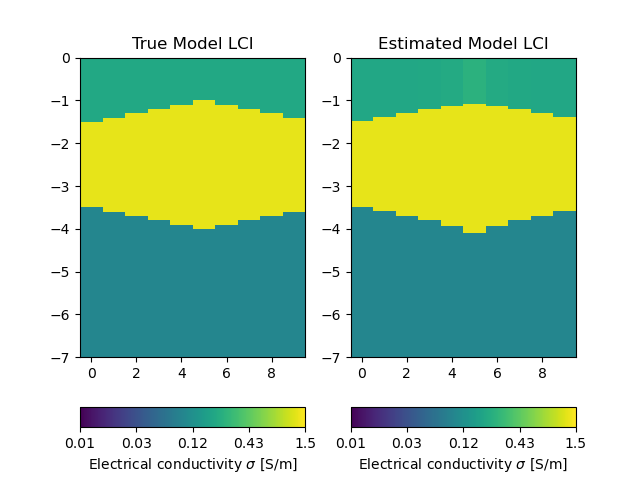

In [161]:
models_est = np.array(models_est).reshape(np.shape(models))

fig, ax = plt.subplots(1,2)

inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 10/1000,
         'cMax': 1500/1000, 
         'logScale':True}

showStitchedModels(ax = ax[1], models=models_est, zMax=7, 
                  title = 'Estimated Model LCI', **inputs)

showStitchedModels(ax = ax[0], models=models, zMax=7, 
                  title = 'True Model LCI', **inputs)


In [162]:
data_est = inv.fop.response(models_est)

# Reshape data arrays [pos, n_components, n_geometries, n_offsets]
data_true = np.array(data_t).reshape(pos,2,3,3)
data_est = np.array(data_est).reshape(pos,2,3,3)

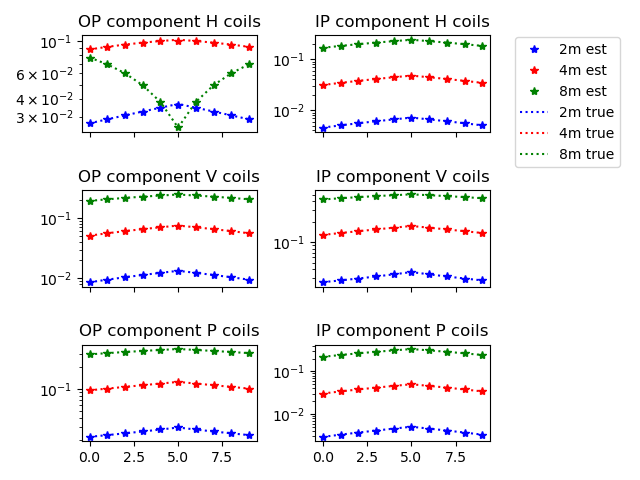

In [163]:
Plot_Datas(data_true, data_est)